Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

GPU detected! Running on CUDA...

Enter Image Prompt: A serene cottage next to a flowing river during autumn, dramatic sunset sky, impressionist oil painting style, warm tones

Generating Image... Please Wait...


  0%|          | 0/50 [00:00<?, ?it/s]

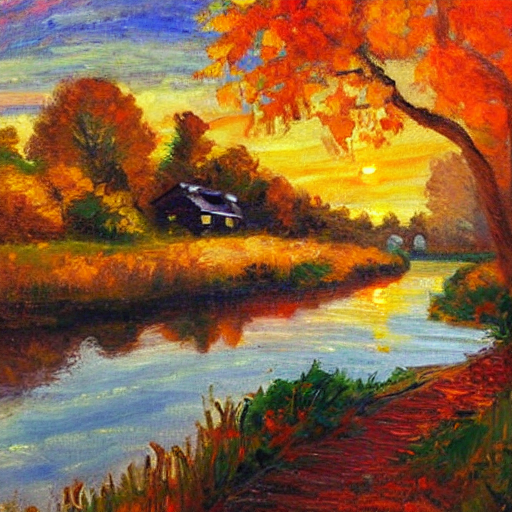


Image Generated Successfully and saved as generated_image.png!


In [3]:
!pip install -q diffusers accelerate

import torch
from diffusers import StableDiffusionPipeline
from PIL import Image
from IPython.display import display

# 1. Load Pretrained Stable Diffusion v1.5 Model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe = pipe.to(device)
if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16
    print("GPU detected! Running on CUDA...")
else:
    device = "cpu"
    dtype = torch.float32
    print("GPU not available. Falling back to CPU (generation will be slower)...")

# 2. Dynamic User Input
user_prompt = input("\nEnter Image Prompt: ")

# 3. Generate & Display Image
print("\nGenerating Image... Please Wait...")
image = pipe(user_prompt).images[0]

display(image)
image.save("generated_image.png")
print("\nImage Generated Successfully and saved as generated_image.png!")